In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve
import joblib


In [26]:
df = pd.read_csv("../data/processed/churn_clean.csv")
df = pd.get_dummies(df, drop_first=True)

In [27]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 5625
Test samples: 1407


In [28]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model, 
        'auc': auc, 
        'y_pred': y_pred, 
        'y_proba': y_proba}
    
    print(f"{name}: AUC = {auc:.4f}")

Logistic Regression: AUC = 0.8357
Random Forest: AUC = 0.8163
Gradient Boosting: AUC = 0.8407


Best model: Gradient Boosting

              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1033
     Churned       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



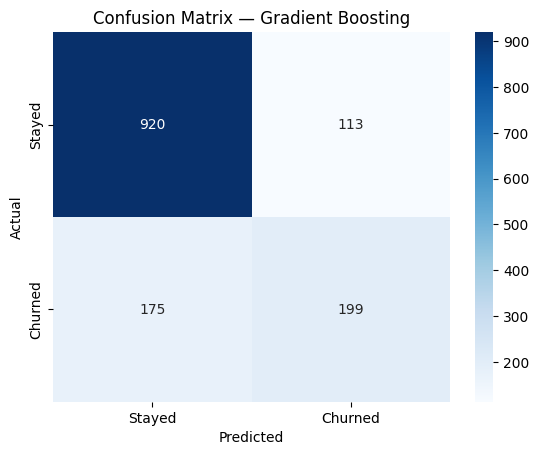

In [29]:
# Pick the best one
best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
print(f"Best model: {best_name}\n")

print(classification_report(y_test, best['y_pred'], target_names=['Stayed', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

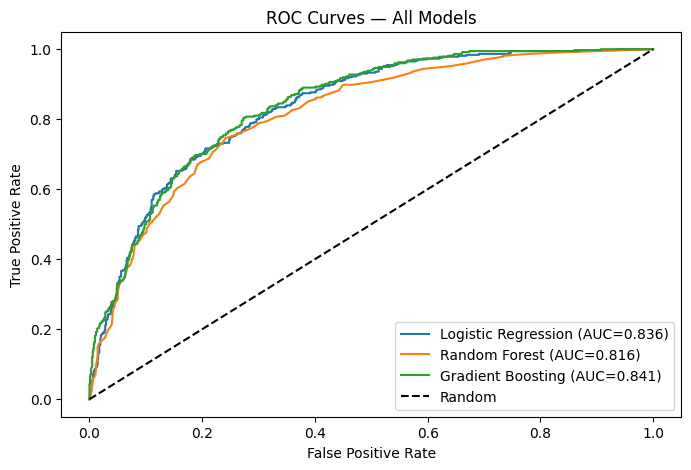

In [30]:
plt.figure(figsize=(8, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()

In [31]:
joblib.dump(best['model'], "../models/churn_model.pkl")

print("Model saved ✓")

Model saved ✓
